In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

import scarf
import scarf.plotting as splt

scarf.configure_output(level='WARNING', progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
    default_assay="RNA",
)

Downloading bucket files: 37077563 / 37077563 complete

Downloading bytes: 37077563 / 37077563 complete

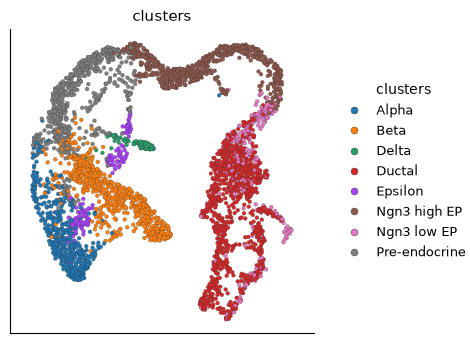

In [2]:
ds.plots.embedding(layout_key="RNA_UMAP", color_by="clusters");

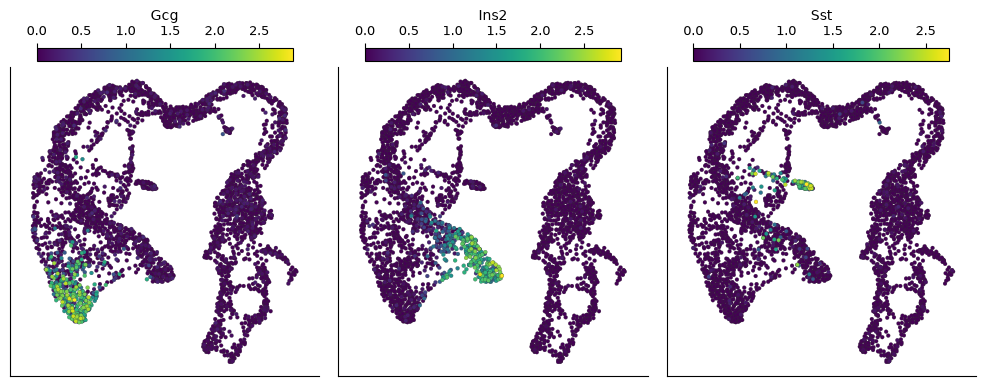

In [3]:
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=["Gcg", "Ins2", "Sst"],
    normalization=splt.NormalizationSpec(transform="log1p"),
    sort_values=True,
);

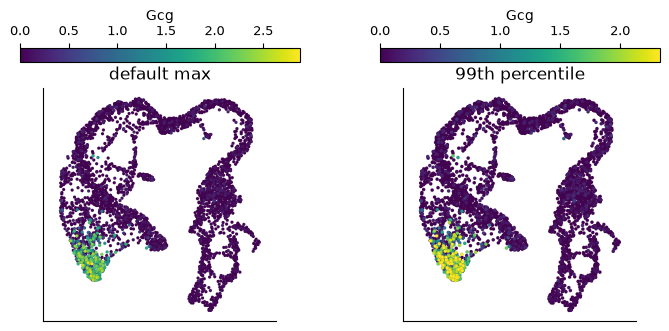

In [4]:
figure, axes = plt.subplots(1, 2, figsize=(7.2, 3.2), layout="constrained")
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="Gcg",
    normalization=splt.NormalizationSpec(transform="log1p"),
    sort_values=True,
    target=axes[0],
    show_titles=False,
    show=False,
)
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="Gcg",
    normalization=splt.NormalizationSpec(transform="log1p"),
    color_scale=splt.ColorScale(cmap="viridis", quantiles=(0.0, 0.99)),
    sort_values=True,
    target=axes[1],
    show_titles=False,
    show=False,
)
axes[0].set_title("default max")
axes[1].set_title("99th percentile")
figure

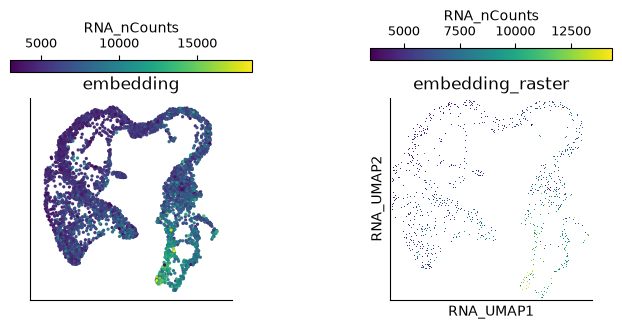

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(7.2, 3.2), layout="constrained")
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="RNA_nCounts",
    target=axes[0],
    show_titles=False,
    show=False,
)
ds.plots.embedding_raster(
    layout_key="RNA_UMAP",
    color_by="RNA_nCounts",
    pixels=400,
    target=axes[1],
    show=False,
)
axes[0].set_title("embedding")
axes[1].set_title("embedding_raster")
figure

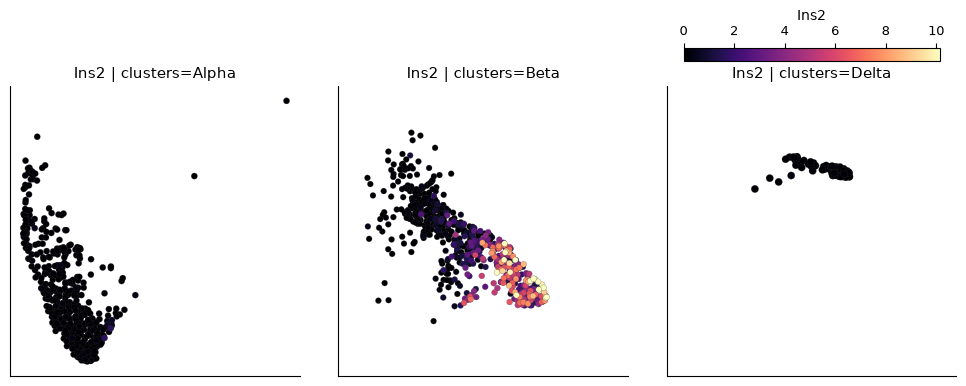

In [6]:
shared_expression_scale = splt.ColorScale(
    cmap="magma",
    quantiles=(0.0, 0.99),
)
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="Ins2",
    facet_by="clusters",
    groups=["Alpha", "Beta", "Delta"],
    color_scale=shared_expression_scale,
    sort_values=True,
    n_columns=3,
);

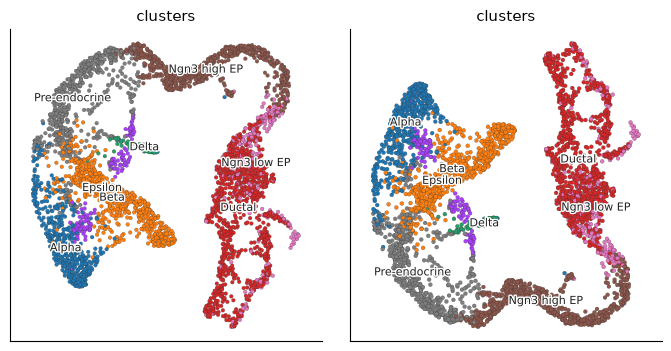

In [7]:
umap1 = ds.cells.fetch("RNA_UMAP1")
umap2 = ds.cells.fetch("RNA_UMAP2")
ds.cells.insert("demo_layout1", umap1, overwrite=True)
ds.cells.insert("demo_layout2", -umap2, overwrite=True)

ds.plots.embedding(
    layout_key=["RNA_UMAP", "demo_layout"],
    color_by="clusters",
    n_columns=2,
    legend_loc="on_data",
);

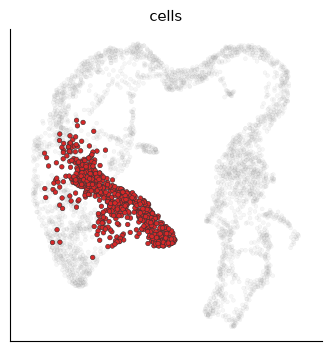

In [8]:
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=None,
    default_color="#bdbdbd",
    point_alpha=0.4,
    highlight=splt.Highlight(
        by="clusters",
        groups=("Beta",),
        color="#d62728",
        dim_alpha=0.12,
        size_multiplier=1.35,
        halo_width=0.4,
    ),
);

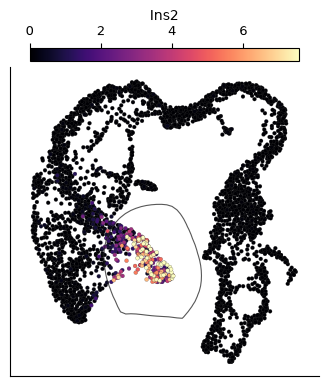

In [9]:
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="Ins2",
    color_scale=shared_expression_scale,
    sort_values=True,
    density_overlay=splt.DensityOverlay(
        statistic="mean",
        pixels=60,
        sigma=4.2,
        min_support=0.35,
        levels=(0.9,),
        max_hotspots=1,
    ),
);

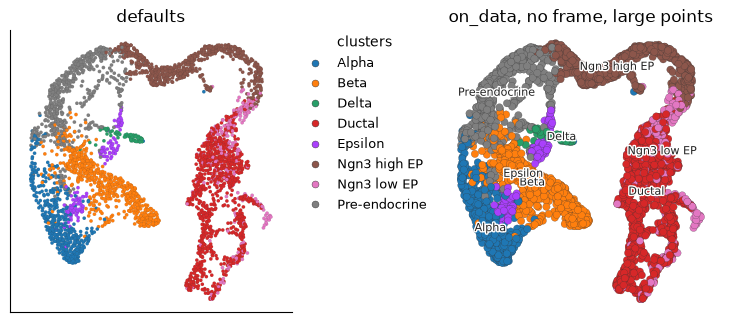

In [10]:
figure, axes = plt.subplots(1, 2, figsize=(7.2, 3.2), layout="constrained")
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="clusters",
    target=axes[0],
    show_titles=False,
    show=False,
)
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="clusters",
    legend_loc="on_data",
    frame="none",
    theme="paper",
    point_size=28,
    target=axes[1],
    show_titles=False,
    show=False,
)
axes[0].set_title("defaults")
axes[1].set_title("on_data, no frame, large points")
figure

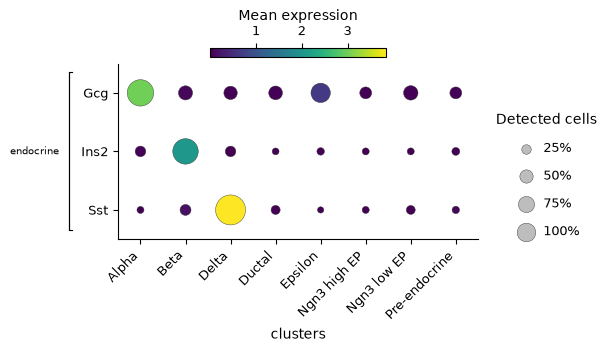

In [11]:
n = len(ds.cells.active_index("I"))
ds.cells.insert(
    "demo_sample",
    [f"s{i % 8}" for i in range(n)],
    overwrite=True,
)

ds.plots.dotplot(
    features={"endocrine": ["Gcg", "Ins2", "Sst"]},
    group_by="clusters",
    sample_by="demo_sample",
);

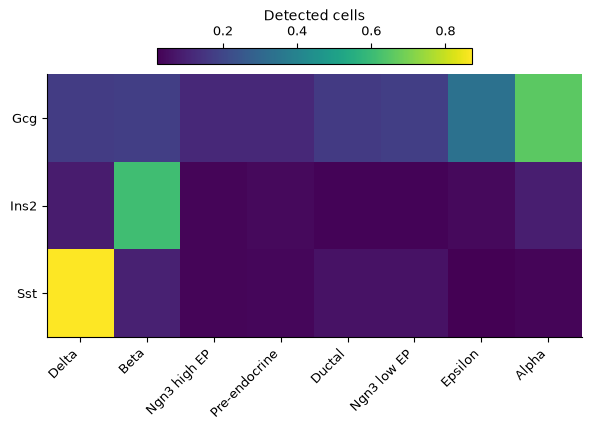

In [12]:
ds.plots.matrixplot(
    features=["Gcg", "Ins2", "Sst"],
    group_by="clusters",
    value="fraction",
    cluster_groups=True,
);

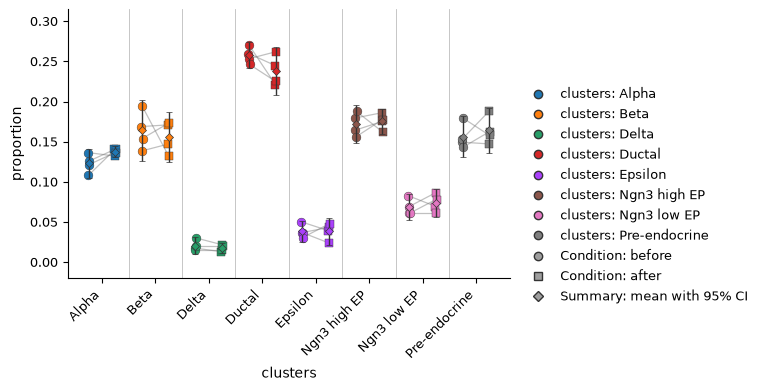

In [13]:
ds.cells.insert(
    "demo_subject",
    [f"d{i % 4}" for i in range(n)],
    overwrite=True,
)
ds.cells.insert(
    "demo_condition",
    ["before" if i % 8 < 4 else "after" for i in range(n)],
    overwrite=True,
)

ds.plots.composition(
    category_by="clusters",
    study_design=splt.StudyDesign(
        sample_by="demo_sample",
        subject_by="demo_subject",
        condition_by="demo_condition",
    ),
    kind="per_sample",
);

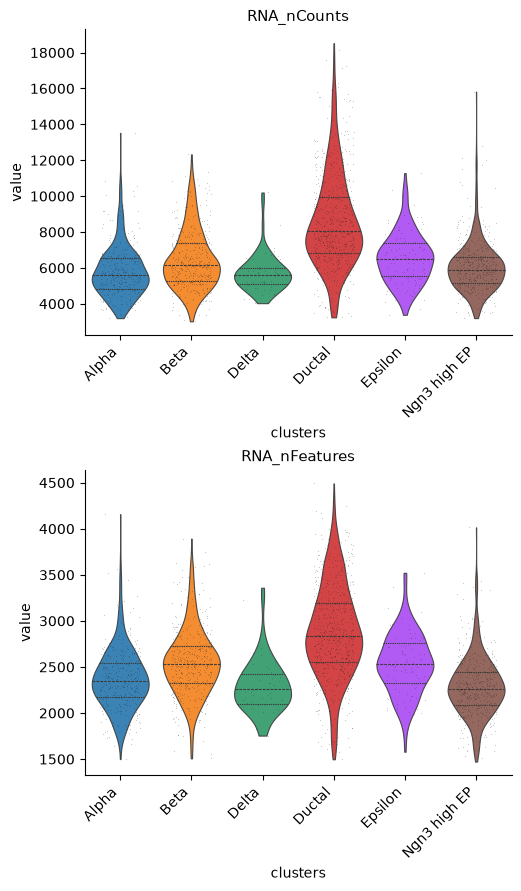

In [14]:
cluster_ids = sorted(set(ds.cells.fetch("clusters")), key=str)[:6]
ds.plots.distribution(
    keys=["RNA_nCounts", "RNA_nFeatures"],
    group_by="clusters",
    groups=cluster_ids,
    kind="violin",
    max_points=2000,
    seed=0,
);

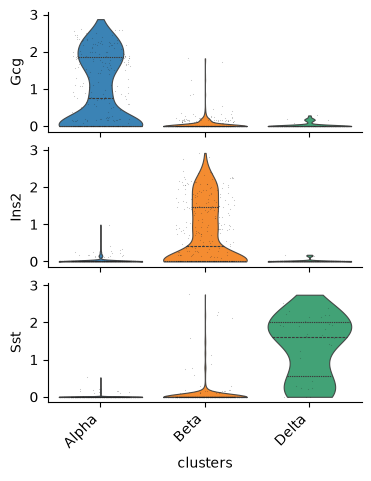

In [15]:
ds.plots.distribution(
    keys=["Gcg", "Ins2", "Sst"],
    group_by="clusters",
    groups=["Alpha", "Beta", "Delta"],
    normalization=splt.NormalizationSpec(transform="log1p"),
    kind="stacked_violin",
    share_y=True,
    max_points=600,
);

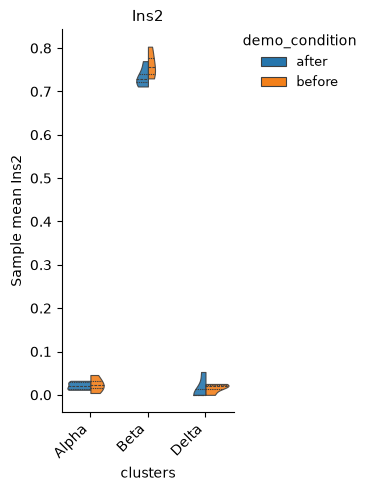

In [16]:
ds.plots.distribution(
    keys="Ins2",
    group_by="clusters",
    groups=["Alpha", "Beta", "Delta"],
    sample_by="demo_sample",
    split_by="demo_condition",
    normalization=splt.NormalizationSpec(transform="log1p"),
    kind="violin",
    max_points=0,
);

In [17]:
out = Path("scarf_datasets") / "plotting_showcase_embedding.png"
out.parent.mkdir(parents=True, exist_ok=True)
result = ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="clusters",
    show=False,
)
result.save(
    out,
    dpi=200,
    exact_size=True,
    provenance_sidecar=True,
)
sidecar = out.with_suffix(out.suffix + ".json")
assert out.exists()
assert sidecar.exists()
print(out)
print(json.dumps(json.loads(sidecar.read_text())["provenance"], indent=2))
result.close()

scarf_datasets/plotting_showcase_embedding.png
{
  "assay": null,
  "cell_key": "I",
  "extras": {
    "assays": [],
    "clip_fraction": 0.0,
    "color_limits": {},
    "color_scale_scope": "feature",
    "density_overlay": null,
    "facet_by": null,
    "groups": null,
    "highlight": null,
    "input_n_cells": 3696,
    "invalid_coordinate_cells": 0,
    "n_colors": 1,
    "n_facets": 1,
    "normalization": {
      "source": "assay",
      "transform": "none"
    },
    "omitted_labels": {},
    "omitted_legend_entries": {},
    "panel_keys": [
      "clusters"
    ],
    "point_edgewidth_by_panel": {
      "clusters": 0.15
    },
    "point_size_by_panel": {
      "clusters": 7.723787032341993
    },
    "point_size_range": [
      1.0,
      28.0
    ],
    "rasterize_threshold": 50000,
    "show_titles": true,
    "sort_values": false,
    "subset_by": null
  },
  "n_cells": 3696,
  "n_samples": null,
  "notes": [
    "embedding",
    "materialized",
    "layout=RNA_UMAP"
  ]

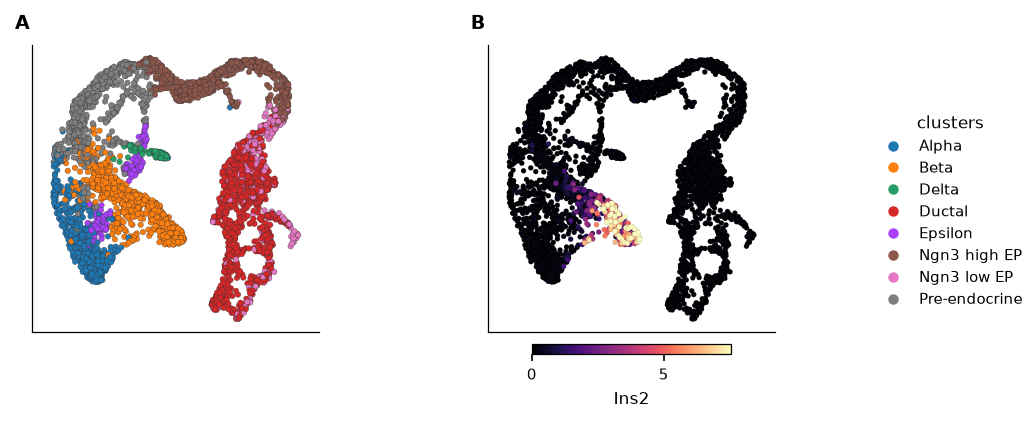

In [18]:
with splt.theme_context("paper"):
    figure, axes = plt.subplots(
        1,
        2,
        figsize=(7.2, 3.2),
        layout="constrained",
    )
    children = {
        "annotation": ds.plots.embedding(
            layout_key="RNA_UMAP",
            color_by="clusters",
            legend_loc="on_data",
            show_legend=False,
            show_titles=False,
            target=axes[0],
            theme="paper",
            show=False,
        ),
        "expression": ds.plots.embedding(
            layout_key="RNA_UMAP",
            color_by="Ins2",
            color_scale=shared_expression_scale,
            sort_values=True,
            show_titles=False,
            target=axes[1],
            theme="paper",
            show=False,
        ),
    }
    composite = splt.compose_results(
        figure,
        children,
        panel_labels=False,
        shared_legends=True,
    )
    splt.label_panels(axes, labels=("A", "B"))
figure

In [19]:
composite_out = (
    Path("scarf_datasets") / "plotting_publication_composite.svg"
)
composite.save(
    composite_out,
    exact_size=True,
    provenance_sidecar=True,
)
composite_sidecar = composite_out.with_suffix(composite_out.suffix + ".json")
print(composite_out)
print(json.dumps(json.loads(composite_sidecar.read_text())["provenance"], indent=2))
plt.close(figure)

scarf_datasets/plotting_publication_composite.svg
{
  "assay": null,
  "cell_key": null,
  "extras": {
    "children": {
      "annotation": {
        "assay": null,
        "cell_key": "I",
        "extras": {
          "assays": [],
          "clip_fraction": 0.0,
          "color_limits": {},
          "color_scale_scope": "feature",
          "density_overlay": null,
          "facet_by": null,
          "groups": null,
          "highlight": null,
          "input_n_cells": 3696,
          "invalid_coordinate_cells": 0,
          "n_colors": 1,
          "n_facets": 1,
          "normalization": {
            "source": "assay",
            "transform": "none"
          },
          "omitted_labels": {},
          "omitted_legend_entries": {},
          "panel_keys": [
            "clusters"
          ],
          "point_edgewidth_by_panel": {
            "clusters": 0.15
          },
          "point_size_by_panel": {
            "clusters": 7.1698363898025725
          },
       